# MetAI v3 - Prevision Meteo Embarquee pour STM32U545RE-Q

**Cible materielle** : NUCLEO-U545RE-Q (STM32U545, Cortex-M33, 256 KB RAM, 2 MB Flash)

## Nouveautes v3 vs v2

| Axe | v2 | v3 |
|-----|----|----|\n
| Features | 18 (t0/t-3h/t-6h + tendances + rosee + heure cyclique) | **9** (t0, t-3h, t-6h : temp, pres, rhum) |
| Objectif | Modele riche offline | **Modele aligne downlink LoRa** (9 valeurs brutes) |
| Buffer MCU | 9 float32 = 36 octets | **idem** (inchange) |
| Inference firmware | METAI_normalize + quantize | **idem** (pipeline simplifie) |

> **Pourquoi v3 ?** Le downlink LoRa envoie exactement `temp_3h, hum_3h, pres_3h, temp_6h, hum_6h, pres_6h`
> plus la lecture courante du capteur. Le modele v3 prend ces 9 valeurs brutes directement,
> sans calcul de tendances ni point de rosee, ce qui simplifie le firmware et reduit la RAM.


In [1]:
# -- Google Drive & dependances ------------------------------------------
from google.colab import drive
drive.mount('/content/gdrive')
import sys, os
PROJECT_DIR = '/content/gdrive/MyDrive/TF_Project'
os.makedirs(PROJECT_DIR, exist_ok=True)
sys.path.append(PROJECT_DIR)
print('Dossier projet :', PROJECT_DIR)

%pip install -q 'pandas>=2.0,<3.0' meteostat


Mounted at /content/gdrive
Dossier projet : /content/gdrive/MyDrive/TF_Project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 108.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 46.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import date
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import meteostat as ms

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles : {len(gpus)}')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print(f'TensorFlow {tf.__version__}')


GPUs disponibles : 1
TensorFlow 2.20.0


In [3]:
# -- 1. Chargement des donnees Meteostat ---------------------------------
# On prend 7 ans (2018-2025) et on interpole depuis les stations proches
# de Thonon-les-Bains pour maximiser la couverture horaire.
ms.config.block_large_requests = False
POINT = ms.Point(46.366, 6.4791, 400)   # Thonon-les-Bains
START = date(2018, 1, 1)
END   = date(2025, 12, 31)

stations = ms.stations.nearby(POINT, limit=6)
PARAMS = [
    ms.Parameter.TEMP, ms.Parameter.PRES, ms.Parameter.RHUM,
    ms.Parameter.PRCP, ms.Parameter.SNOW, ms.Parameter.WSPD,
    ms.Parameter.COCO,
]
ts  = ms.hourly(stations, START, END, parameters=PARAMS)
df = ms.interpolate(ts, POINT).fetch()
if df is None or df.empty:
    raise RuntimeError("Aucune donnee meteostat. Verifiez connexion / dates.")

def safe_col(df, param, fill=float('nan')):
    return df[param].to_numpy(dtype=np.float32) if param in df.columns \
           else np.full(len(df), fill, dtype=np.float32)

temp  = safe_col(df, ms.Parameter.TEMP)
pres  = safe_col(df, ms.Parameter.PRES)
rhum  = safe_col(df, ms.Parameter.RHUM)
prcp  = safe_col(df, ms.Parameter.PRCP, 0.0)
snow  = safe_col(df, ms.Parameter.SNOW, 0.0)
wspd  = safe_col(df, ms.Parameter.WSPD, 0.0)
coco  = safe_col(df, ms.Parameter.COCO, float('nan'))
dates = df.index.to_numpy()

print(f'Donnees chargees : {len(df):,} heures ({START} -> {END})')
print(df[['temp', 'pres', 'rhum']].describe().round(2))


Donnees chargees : 70,128 heures (2018-01-01 -> 2025-12-31)
          temp     pres     rhum
count  70128.0  70128.0  70128.0
mean     12.24  1017.65    73.72
std       7.49      7.9    14.37
min       -9.1    980.4     18.0
25%        6.2   1013.3     64.0
50%       11.7   1017.5     76.0
75%       17.8   1022.1     85.0
max       35.1   1043.2    100.0


In [4]:
# -- 2. Taxonomie 7 classes (coherentes avec 3 capteurs) ----------------
#
# Suppressions vs v2 (9 classes) :
#   - 'Peu nuageux'          -> fusionne dans 'Clair / Ensoleille'
#     (indetectable sans capteur UV/luminosite ; matrice de confusion confirmait
#      la confusion avec Clair et Partiellement nuageux)
#   - 'Partiellement nuageux' -> fusionne dans 'Nuageux / Couvert'
#     (meme raison ; pression/temp/rhum ne discriminent pas le taux de couverture
#      nuageuse partiel ; absorbe naturellement dans Nuageux)
#
# Nouvelle taxonomie (7 classes, indices 0-6) :
#   0  Clair / Ensoleille    <- ancien 0 + ancien 1 (Peu nuageux)
#   1  Nuageux / Couvert     <- ancien 3 + ancien 2 (Partiellement nuageux)
#   2  Pluie                 <- ancien 4
#   3  Averses               <- ancien 5
#   4  Neige                 <- ancien 6
#   5  Orage                 <- ancien 7
#   6  Brouillard / Brume    <- ancien 8

CLASSES = [
    'Clair / Ensoleille',    # 0  (inclut ancien Peu nuageux)
    'Nuageux / Couvert',     # 1  (inclut ancien Partiellement nuageux)
    'Pluie',                 # 2
    'Averses',               # 3
    'Neige',                 # 4
    'Orage',                 # 5
    'Brouillard / Brume',    # 6
]
NUM_CLASSES = len(CLASSES)
print(f'Nombre de classes : {NUM_CLASSES}')
for i, c in enumerate(CLASSES):
    print(f'  {i}: {c}')


def map_coco_to_class(coco_val, prcp_val, snow_val, wspd_val, temp_val):
    '''Mappe le code COCO Meteostat vers l une des 7 classes.
    Peu nuageux (COCO 2) -> 0 (Clair).
    Partiellement nuageux (COCO 3) -> 1 (Nuageux).
    '''
    c = int(coco_val) if np.isfinite(coco_val) else -1
    p = float(prcp_val) if np.isfinite(prcp_val) else 0.0
    s = float(snow_val)  if np.isfinite(snow_val)  else 0.0
    t = float(temp_val)  if np.isfinite(temp_val)  else 5.0

    if c in (1, 2):         return 0   # Clair + Peu nuageux -> Clair
    if c in (3, 4):         return 1   # Partiellement nuageux + Nuageux -> Nuageux
    if c in (5, 6):         return 6   # Brouillard
    if c in (15, 16, 17):   return 5   # Orage
    if c in (7, 8, 9):      return 2 if p >= 0.5 else 3  # Pluie / Averses
    if c in (10, 11):       return 4 if t < 2.0 else 2   # Pluie+neige melees
    if c in (12, 13, 14):   return 4   # Neige

    # Fallback physique
    if s > 0.1: return 4
    if p > 0.5: return 2
    if p > 0.0: return 3
    return 1   # defaut : couvert


Nombre de classes : 7
  0: Clair / Ensoleille
  1: Nuageux / Couvert
  2: Pluie
  3: Averses
  4: Neige
  5: Orage
  6: Brouillard / Brume


In [5]:
# -- 3. Feature Engineering : 9 features (t0, t-3h, t-6h) -------------
#
# Chaque echantillon contient 9 features :
#   [0-2]   Valeurs courantes t0   : temp, pres, rhum
#   [3-5]   Valeurs a t-3h         : temp, pres, rhum
#   [6-8]   Valeurs a t-6h         : temp, pres, rhum
#
# Avantage : correspond exactement aux donnees envoyees par downlink LoRa.
# Le MCU n'a besoin d'aucun calcul supplementaire avant l'inference.
#
# MCU : buffer circulaire de 3 lectures x 3 capteurs = 9 float32 = 36 octets

FEAT_NAMES = [
    'temp_t0', 'pres_t0', 'rhum_t0',
    'temp_t3', 'pres_t3', 'rhum_t3',
    'temp_t6', 'pres_t6', 'rhum_t6',
]
NUM_FEATURES = len(FEAT_NAMES)


def build_features(temp_a, pres_a, rhum_a, dates_a):
    T3, T6 = 3, 6
    N = len(temp_a)
    rows, valid_idx = [], []

    for i in range(T6, N):
        t0, p0, h0 = temp_a[i],      pres_a[i],      rhum_a[i]
        t3, p3, h3 = temp_a[i - T3], pres_a[i - T3], rhum_a[i - T3]
        t6, p6, h6 = temp_a[i - T6], pres_a[i - T6], rhum_a[i - T6]
        if not all(np.isfinite(v) for v in [t0, p0, h0, t3, p3, h3, t6, p6, h6]):
            continue

        rows.append([t0, p0, h0, t3, p3, h3, t6, p6, h6])
        valid_idx.append(i)

    return np.array(rows, dtype=np.float32), np.array(valid_idx, dtype=np.int32)


X_raw, valid_idx = build_features(temp, pres, rhum, dates)
print(f'Features : {X_raw.shape[1]} par echantillon')
print(f'Echantillons valides : {len(X_raw):,}')
for i, n in enumerate(FEAT_NAMES):
    print(f'  [{i:2d}] {n}')


Features : 9 par echantillon
Echantillons valides : 70,122
  [ 0] temp_t0
  [ 1] pres_t0
  [ 2] rhum_t0
  [ 3] temp_t3
  [ 4] pres_t3
  [ 5] rhum_t3
  [ 6] temp_t6
  [ 7] pres_t6
  [ 8] rhum_t6


In [6]:
# -- 4. Labels, normalisation, split ------------------------------------
y_raw = np.array([
    map_coco_to_class(coco[i], prcp[i], snow[i], wspd[i], temp[i])
    for i in valid_idx
], dtype=np.int32)

print(f'Dataset : {len(X_raw):,} echantillons')
print('\nDistribution des classes :')
cnt = Counter(y_raw)
for idx in sorted(cnt):
    pct = 100 * cnt[idx] / len(y_raw)
    bar = '#' * int(40 * cnt[idx] / len(y_raw))
    print(f'  [{idx}] {CLASSES[idx]:<28} {cnt[idx]:6,}  {pct:5.1f}%  {bar}')

# Normalisation min-max  (stockee pour le header C)
X_min   = X_raw.min(axis=0)
X_max   = X_raw.max(axis=0)
X_range = np.where((X_max - X_min) < 1e-6, 1.0, X_max - X_min)
X_norm  = ((X_raw - X_min) / X_range).astype(np.float32)

# Split stratifie 80/20
x_train, x_test, y_train, y_test = train_test_split(
    X_norm, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)
print(f'\nTrain : {len(x_train):,}   Test : {len(x_test):,}')

from sklearn.utils.class_weight import compute_class_weight
cw_vals = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weight = {i: float(w) for i, w in enumerate(cw_vals)}
print('\nClass weights:')
for i, w in class_weight.items():
    print(f'  [{i}] {CLASSES[i]:<28} w={w:.3f}')



Dataset : 70,122 echantillons

Distribution des classes :
  [0] Clair / Ensoleille           28,920   41.2%  ################
  [1] Nuageux / Couvert            29,070   41.5%  ################
  [2] Pluie                         3,421    4.9%  #
  [3] Averses                       7,201   10.3%  ####
  [4] Neige                           687    1.0%  
  [5] Orage                           610    0.9%  
  [6] Brouillard / Brume              213    0.3%  

Train : 56,097   Test : 14,025

Class weights:
  [0] Clair / Ensoleille           w=0.346
  [1] Nuageux / Couvert            w=0.345
  [2] Pluie                        w=2.928
  [3] Averses                      w=1.391
  [4] Neige                        w=14.597
  [5] Orage                        w=16.422
  [6] Brouillard / Brume           w=47.140


In [7]:
# -- 5. Focal Loss (gamma=2) ---------------------------------------------
#
# FL(p_t) = -(1 - p_t)^gamma * log(p_t)
#
# Le facteur (1-p_t)^gamma reduit automatiquement la contribution
# des exemples faciles (bien classes) et se concentre sur les cas
# difficiles (Orage, Neige) sans clip de class_weight arbitraire.

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers


class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce     = -y_true * tf.math.log(y_pred)
        p_t    = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal  = tf.pow(1.0 - p_t, self.gamma) * ce
        return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma})
        return cfg


print('Focal Loss definie.')


Focal Loss definie.


In [8]:
# -- 6. Architecture : Residual MLP compact -----------------------------
#
# Entree : 9 features (temp/pres/rhum x t0/t-3h/t-6h)
# Sortie : 7 classes meteo
#
# L architecture reste identique a v2 (Residual MLP) mais le premier
# bloc est reduit (48 unites au lieu de 64) car le vecteur d entree
# est plus petit (9 vs 18 features).
#
# Budget memoire cible (STM32U545) :
#   Flash  : < 80 KB INT8
#   RAM    : < 3 KB (activations)

L2 = 1e-4


def residual_block(x, units, dropout=0.0):
    shortcut = x
    if x.shape[-1] != units:
        shortcut = layers.Dense(units, use_bias=False,
                                kernel_regularizer=regularizers.l2(L2))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    h = layers.Dense(units, use_bias=False,
                     kernel_regularizer=regularizers.l2(L2))(x)
    h = layers.BatchNormalization()(h)
    h = layers.Activation('relu')(h)
    h = layers.Dense(units, use_bias=False,
                     kernel_regularizer=regularizers.l2(L2))(h)
    h = layers.BatchNormalization()(h)

    out = layers.Add()([h, shortcut])
    out = layers.Activation('relu')(out)
    if dropout > 0:
        out = layers.Dropout(dropout)(out)
    return out


def build_model(num_features, num_classes):
    inp = layers.Input(shape=(num_features,), name='sensor_input')

    # Projection initiale (48 au lieu de 64 : entree plus petite)
    x = layers.Dense(48, use_bias=False,
                     kernel_regularizer=regularizers.l2(L2), name='stem')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Blocs residuels
    x = residual_block(x, 48, dropout=0.10)
    x = residual_block(x, 32, dropout=0.08)
    x = residual_block(x, 24)

    out = layers.Dense(num_classes, activation='softmax',
                       name='weather_class')(x)
    return models.Model(inp, out, name='metai_v3')


model = build_model(NUM_FEATURES, NUM_CLASSES)
model.summary()

p = model.count_params()
print(f'\nParams totaux  : {p:,}')
print(f'Taille FP32    : {p*4/1024:.1f} KB')
print(f'Taille INT8 est: {p/1024:.1f} KB  (budget Flash STM32)')


Model: "metai_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem (Dense)        │ (None, 48)        │        432 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48)        │        192 │ stem[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 48)        │      2,304 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48)        │        192 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 48)        │      2,304 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48)        │        192 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48)        │          0 │ batch_normalizat… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48)        │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48)        │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,536 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      1,024 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,536 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 12,671 (49.50 KB)

 Trainable params: 12,047 (47.06 KB)

 Non-trainable params: 624 (2.44 KB)


Params totaux  : 12,671
Taille FP32    : 49.5 KB
Taille INT8 est: 12.4 KB  (budget Flash STM32)


In [9]:
# -- 7. Entrainement : Cosine Annealing Warm Restarts + AdamW -----------
import math

LR_MAX = 1e-3
LR_MIN = 5e-6
T0     = 40
T_MULT = 2


class CosineAnnealingWR(tf.keras.callbacks.Callback):
    '''SGDR - compatible Keras 3 / TF >= 2.16 (pas de backend.set_value).'''
    def __init__(self, lr_max, lr_min, T0, T_mult=2):
        super().__init__()
        self.lr_max     = lr_max
        self.lr_min     = lr_min
        self.T_cur      = 0
        self.T_i        = T0
        self.T_mult     = T_mult
        self.lr_history = []

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (
            1.0 + math.cos(math.pi * self.T_cur / self.T_i)
        )
        self.model.optimizer.learning_rate = float(lr)
        self.lr_history.append(lr)
        if self.T_cur >= self.T_i:
            self.T_cur = 0
            self.T_i   = int(self.T_i * self.T_mult)
        else:
            self.T_cur += 1

    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            logs['lr'] = float(self.model.optimizer.learning_rate)


model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LR_MAX, weight_decay=1e-4),
    loss=FocalLoss(gamma=2.0, name='focal_loss'),
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
    ],
)

BATCH_SIZE = 256
EPOCHS     = 150

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
    .shuffle(10000, seed=42, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

lr_callback = CosineAnnealingWR(LR_MAX, LR_MIN, T0, T_MULT)

callbacks = [
    lr_callback,
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(PROJECT_DIR, 'best_metai_v3.keras'),
        monitor='val_accuracy', mode='max',
        save_best_only=True, verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', mode='max',
        patience=30, restore_best_weights=True, verbose=1,
    ),
]

print('Debut de l entrainement...')
print(f'LR_MAX={LR_MAX}, T0={T0}, BATCH={BATCH_SIZE}, classes={NUM_CLASSES}')

history = model.fit(
    train_ds, epochs=EPOCHS,
    validation_data=test_ds,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)

best_acc   = float(max(history.history['val_accuracy']))
best_epoch = int(history.history['val_accuracy'].index(
                 max(history.history['val_accuracy']))) + 1
print(f'\nMeilleure val_accuracy : {best_acc:.4f} (epoch {best_epoch})')


Debut de l entrainement...
LR_MAX=0.001, T0=40, BATCH=256, classes=7
Epoch 1/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4818 - loss: 0.8511 - top3_acc: 0.8338
Epoch 1: val_accuracy improved from None to 0.54396, saving model to /content/gdrive/MyDrive/TF_Project/best_metai_v3.keras

Epoch 1: finished saving model to /content/gdrive/MyDrive/TF_Project/best_metai_v3.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.5644 - loss: 0.6350 - top3_acc: 0.9177 - val_accuracy: 0.5440 - val_loss: 0.6166 - val_top3_acc: 0.9306 - lr: 0.0010
Epoch 2/150
214/220 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6155 - loss: 0.4641 - top3_acc: 0.9643
Epoch 2: val_accuracy improved from 0.54396 to 0.58610, saving model to /content/gdrive/MyDrive/TF_Project/best_metai_v3.keras

Epoch 2: finished saving model to /content/gdrive/MyDrive/TF_Project/best_metai_v3.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6202 - loss: 0.4549 - top3_acc: 0.9664 - val_accuracy: 0.5

Test top-1 accuracy : 0.6902
Test top-3 accuracy : 0.9822

-- Classification Report ---
                    precision    recall  f1-score   support

Clair / Ensoleille      0.782     0.821     0.801      5784
 Nuageux / Couvert      0.658     0.711     0.684      5814
             Pluie      0.500     0.224     0.309       684
           Averses      0.462     0.401     0.429      1440
             Neige      0.528     0.413     0.463       138
             Orage      0.000     0.000     0.000       122
Brouillard / Brume      0.700     0.163     0.264        43

          accuracy                          0.690     14025
         macro avg      0.519     0.390     0.422     14025
      weighted avg      0.675     0.690     0.679     14025



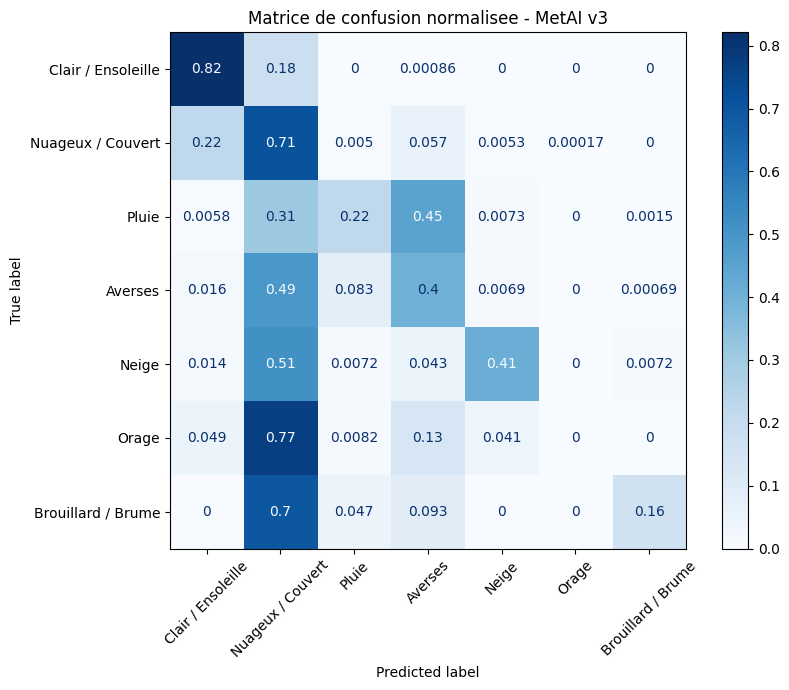

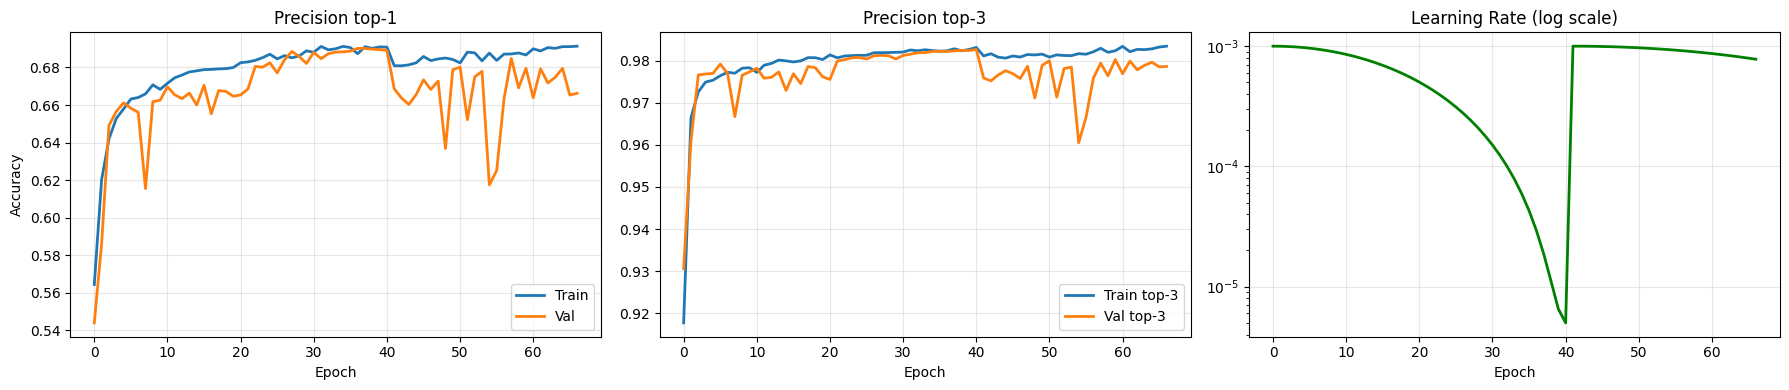

In [10]:
# -- 8. Evaluation detaillee ---------------------------------------------
test_loss, test_acc, test_top3 = model.evaluate(x_test, y_test_cat, verbose=0)
print(f'Test top-1 accuracy : {test_acc:.4f}')
print(f'Test top-3 accuracy : {test_top3:.4f}')

y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
print('\n-- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))

# Matrice de confusion normalisee
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Matrice de confusion normalisee - MetAI v3')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'confusion_matrix_v3.png'), dpi=150)
plt.show()

# Courbes d entrainement (top-1, top-3, LR schedule)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history['accuracy'],     label='Train', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   lw=2)
axes[0].set_title('Precision top-1')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['top3_acc'],     label='Train top-3', lw=2)
axes[1].plot(history.history['val_top3_acc'], label='Val top-3',   lw=2)
axes[1].set_title('Precision top-3')
axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

if hasattr(lr_callback, 'lr_history') and lr_callback.lr_history:
    axes[2].semilogy(lr_callback.lr_history, color='green', lw=2)
    axes[2].set_title('Learning Rate (log scale)')
    axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'training_curves_v3.png'), dpi=150)
plt.show()


In [11]:
# -- 9. Quantification INT8 Full-Integer (pour Cube AI / STEdgeAI) ------
#
# Cube AI / STEdgeAI sur STM32U5 requiert une quantification FULL INTEGER :
#   - Tous les ops en INT8 (poids, biais, activations)
#   - Tenseurs d entree et de sortie aussi en INT8
#   - Un 'representative dataset' est necessaire pour calibrer les
#     plages de quantification (500 echantillons suffisent en pratique)
#
# Benefices sur Cortex-M33 :
#   - Taille du modele : x4 plus petite
#   - Latence          : x2 a x4 plus rapide (instructions SIMD DSP)


def representative_dataset_gen():
    idx = np.random.choice(len(x_test), 500, replace=False)
    for i in idx:
        yield [x_test[i:i+1].astype(np.float32)]


# -- Export FP32 (reference)
conv_fp32 = tf.lite.TFLiteConverter.from_keras_model(model)
tfl_fp32  = conv_fp32.convert()
fp32_path = os.path.join(PROJECT_DIR, 'metai_v3_fp32.tflite')
open(fp32_path, 'wb').write(tfl_fp32)
print(f'FP32 TFLite : {len(tfl_fp32)/1024:.1f} KB  ->  {fp32_path}')

# -- Export INT8 Full-Integer
conv_i8 = tf.lite.TFLiteConverter.from_keras_model(model)
conv_i8.optimizations                 = [tf.lite.Optimize.DEFAULT]
conv_i8.representative_dataset        = representative_dataset_gen
conv_i8.target_spec.supported_ops     = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_i8.inference_input_type          = tf.int8   # entree INT8
conv_i8.inference_output_type         = tf.int8   # sortie INT8
tfl_i8   = conv_i8.convert()
int8_path = os.path.join(PROJECT_DIR, 'metai_v3_int8.tflite')
open(int8_path, 'wb').write(tfl_i8)
print(f'INT8 TFLite : {len(tfl_i8)/1024:.1f} KB  ->  {int8_path}')
print(f'Ratio compression : x{len(tfl_fp32)/len(tfl_i8):.1f}')

# -- Recuperation des parametres de quantification
interp = tf.lite.Interpreter(model_content=tfl_i8)
interp.allocate_tensors()
inp_det = interp.get_input_details()[0]
out_det = interp.get_output_details()[0]
inp_scale, inp_zp = inp_det['quantization']
out_scale, out_zp = out_det['quantization']
print(f'\nQuantif entree : scale={inp_scale:.7f}, zero_point={inp_zp}')
print(f'Quantif sortie : scale={out_scale:.7f}, zero_point={out_zp}')

# -- Validation rapide INT8 sur 300 echantillons
rand_idx = np.random.choice(len(x_test), 300, replace=False)
n_ok = 0
for i in rand_idx:
    samp = np.clip(np.round(x_test[i:i+1] / inp_scale + inp_zp), -128, 127).astype(np.int8)
    interp.set_tensor(inp_det['index'], samp)
    interp.invoke()
    out  = interp.get_tensor(out_det['index'])[0]
    prob = (out.astype(np.float32) - out_zp) * out_scale
    if int(np.argmax(prob)) == int(y_test[i]):
        n_ok += 1
int8_acc = n_ok / 300
print(f'\nPrecision INT8 (300 echantillons) : {int8_acc:.3f}')
print(f'Degradation vs FP32               : {test_acc - int8_acc:+.3f}')


Saved artifact at '/tmp/tmpsq7mh3ix'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9), dtype=tf.float32, name='sensor_input')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  133796411227984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133793781630736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133793781631120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133796411225680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133796411225104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133796411227600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133793781629776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133793781631888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133793781631504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133793781631312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133793781629584: TensorS

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [12]:
# -- 10. Export header C pour le firmware STM32 -------------------------
#
# Le header contient :
#   - Dimensions du modele (9 features, 7 classes)
#   - Vecteurs X_min et X_range pour la normalisation min-max
#   - Parametres de quantification INT8 (scale/zero_point entree et sortie)
#   - Noms des classes et des features (UART debug)
#   - Fonctions METAI_normalize() et METAI_quantize_input() inline

def c_float_array(name, arr):
    vals = ', '.join(f'{v:.7f}f' for v in arr)
    return f'static const float {name}[{len(arr)}] = {{{vals}}};'

classes_c  = ',\n  '.join(f'"{c}"' for c in CLASSES)
features_c = ',\n  '.join(f'"{n}"' for n in FEAT_NAMES)

header_lines = [
    '/**',
    ' * @file   metai_v3_config.h',
    ' * @brief  Configuration MetAI v3 pour STM32U545RE-Q',
    ' *         9 features : temp/pres/rhum a t0, t-3h, t-6h',
    ' *         Aligne avec le downlink LoRa (hum_3h, pres_3h, temp_3h, ...)',
    ' *         Genere automatiquement par le notebook MetAI_v3.',
    ' *',
    ' * Workflow firmware :',
    ' *   1. Charger metai_v3_int8.tflite dans CubeAI / STEdgeAI',
    ' *   2. Inclure ce header dans Core/Inc/',
    ' *   3. Appeler METAI_normalize() puis METAI_quantize_input()',
    ' *      avant chaque appel ai_run().',
    ' */',
    '#pragma once',
    '#include <stdint.h>',
    '#include <math.h>',
    '',
    '/* -- Dimensions ---------------------------------------------------- */',
    f'#define METAI_NUM_FEATURES  {NUM_FEATURES}  /* 9 : temp/pres/rhum x (t0, t-3h, t-6h) */',
    f'#define METAI_NUM_CLASSES   {NUM_CLASSES}',
    '',
    '/* -- Ordre des features -------------------------------------------- */',
    '/* raw[0]=temp_t0  raw[1]=pres_t0  raw[2]=rhum_t0                     */',
    '/* raw[3]=temp_t3  raw[4]=pres_t3  raw[5]=rhum_t3  (downlink t-3h)   */',
    '/* raw[6]=temp_t6  raw[7]=pres_t6  raw[8]=rhum_t6  (downlink t-6h)   */',
    '',
    '/* -- Normalisation min-max ----------------------------------------- */',
    c_float_array('METAI_X_MIN',   X_min),
    c_float_array('METAI_X_RANGE', X_range),
    '',
    '/* -- Quantification INT8 ------------------------------------------ */',
    f'#define METAI_INPUT_SCALE       {inp_scale:.8f}f',
    f'#define METAI_INPUT_ZERO_POINT  {inp_zp}',
    f'#define METAI_OUTPUT_SCALE      {out_scale:.8f}f',
    f'#define METAI_OUTPUT_ZERO_POINT {out_zp}',
    '',
    '/* -- Noms des classes (UART debug) --------------------------------- */',
    f'static const char* const METAI_CLASS_NAMES[{NUM_CLASSES}] = {{',
    f'  {classes_c}',
    '};',
    '',
    '/* -- Noms des features (UART debug) -------------------------------- */',
    f'static const char* const METAI_FEAT_NAMES[{NUM_FEATURES}] = {{',
    f'  {features_c}',
    '};',
    '',
    '/* -- Normalisation inline ------------------------------------------ */',
    'static inline void METAI_normalize(const float* raw, float* norm) {',
    '  for (int i = 0; i < METAI_NUM_FEATURES; i++) {',
    '    float v = (raw[i] - METAI_X_MIN[i]) / METAI_X_RANGE[i];',
    '    if (v < 0.0f) v = 0.0f;',
    '    if (v > 1.0f) v = 1.0f;',
    '    norm[i] = v;',
    '  }',
    '}',
    '',
    '/* -- Quantification entree inline ---------------------------------- */',
    'static inline void METAI_quantize_input(const float* norm, int8_t* quant) {',
    '  for (int i = 0; i < METAI_NUM_FEATURES; i++) {',
    '    float q = norm[i] / METAI_INPUT_SCALE + (float)METAI_INPUT_ZERO_POINT;',
    '    if (q >  127.0f) q =  127.0f;',
    '    if (q < -128.0f) q = -128.0f;',
    '    quant[i] = (int8_t)(q + 0.5f);',
    '  }',
    '}',
    '',
    '/* -- Decodage sortie inline ---------------------------------------- */',
    'static inline uint8_t METAI_decode_output(const int8_t* out_i8) {',
    '  uint8_t best = 0;',
    '  int8_t  bval = out_i8[0];',
    '  for (int i = 1; i < METAI_NUM_CLASSES; i++) {',
    '    if (out_i8[i] > bval) { bval = out_i8[i]; best = (uint8_t)i; }',
    '  }',
    '  return best;',
    '}',
]

header_text = '\n'.join(header_lines)
hdr_path = os.path.join(PROJECT_DIR, 'metai_v3_config.h')
with open(hdr_path, 'w') as f:
    f.write(header_text)
print(f'Header C ecrit : {hdr_path}')
print(f'Taille : {len(header_text)} octets')
print('\nExtrait :')
print(header_text[:600])


Header C ecrit : /content/gdrive/MyDrive/TF_Project/metai_v3_config.h
Taille : 3170 octets

Extrait :
/**
 * @file   metai_v3_config.h
 * @brief  Configuration MetAI v3 pour STM32U545RE-Q
 *         9 features : temp/pres/rhum a t0, t-3h, t-6h
 *         Aligne avec le downlink LoRa (hum_3h, pres_3h, temp_3h, ...)
 *         Genere automatiquement par le notebook MetAI_v3.
 *
 * Workflow firmware :
 *   1. Charger metai_v3_int8.tflite dans CubeAI / STEdgeAI
 *   2. Inclure ce header dans Core/Inc/
 *   3. Appeler METAI_normalize() puis METAI_quantize_input()
 *      avant chaque appel ai_run().
 */
#pragma once
#include <stdint.h>
#include <math.h>

/* -- Dimensions ---------------------------


In [13]:
# -- 11. Fonction d inference Python (simule le firmware STM32) ---------
#
# Reproduit exactement la chaine embarquee v3 :
#   buffer circulaire (9 valeurs) -> METAI_normalize -> METAI_quantize_input
#   -> ai_run (TFLite INT8) -> METAI_decode_output
#
# Entree : 3 tuples (temp, pres, rhum) pour t0, t-3h, t-6h
# Correspond directement aux valeurs du downlink LoRa.


def predict_weather_int8(readings_6h):
    '''
    readings_6h : 3 tuples [(temp,pres,rhum), ...]
                  index 0 = maintenant (t0)
                  index 1 = t-3h  (valeurs du downlink : temp_3h, pres_3h, hum_3h)
                  index 2 = t-6h  (valeurs du downlink : temp_6h, pres_6h, hum_6h)
    Retourne (class_idx, probs_float32)
    '''
    (t0, p0, h0), (t3, p3, h3), (t6, p6, h6) = readings_6h

    raw = np.array([[t0, p0, h0, t3, p3, h3, t6, p6, h6]], dtype=np.float32)

    norm = np.clip((raw - X_min) / X_range, 0.0, 1.0).astype(np.float32)
    qin  = np.clip(np.round(norm / inp_scale + inp_zp), -128, 127).astype(np.int8)

    interp.set_tensor(inp_det['index'], qin)
    interp.invoke()
    out  = interp.get_tensor(out_det['index'])[0]
    prob = np.clip((out.astype(np.float32) - out_zp) * out_scale, 0.0, None)
    prob /= prob.sum() + 1e-9
    return int(np.argmax(prob)), prob


def print_weather(readings_6h, label=''):
    idx, prob = predict_weather_int8(readings_6h)
    top3 = np.argsort(prob)[-3:][::-1]
    print(f'\n=== {label} ===')
    print(f'Prediction : {CLASSES[idx]}  ({prob[idx]:.1%})')
    print('Top 3 :')
    for i in top3:
        bar = '#' * int(30 * prob[i])
        print(f'  [{i}] {CLASSES[i]:<28} {prob[i]:.1%}  {bar}')


# -- Tests avec donnees realistes (t0, t-3h, t-6h)
# Format : (temp_t0, pres_t0, rhum_t0), (temp_t3, pres_t3, rhum_t3), (temp_t6, pres_t6, rhum_t6)
print_weather([(24,1020,40),(23,1019,42),(22,1018,45)], 'Beau temps (anticyclone)')
print_weather([(10,1005,92),(11,1007,88),(12,1009,82)], 'Pluie (depression)')
print_weather([(-2,1000,95),(-1,1002,91),(1,1005,86)], 'Neige (sous zero)')
print_weather([(8,1014,98),(8,1014,97),(9,1013,95)],   'Brouillard matinal')
print_weather([(18,985,75),(20,990,68),(22,996,60)],   'Approche orage (pression chute)')

# -- Simulation donnees LoRa (exemple live depuis TTN)
print('\n--- Simulation donnees LoRa (comme recu par downlink) ---')
lora_payload = {
    'temperature_C': 17,
    'humidity_pct':  62,
    'pressure_hPa':  962.4,
    'temp_3h': 31, 'hum_3h': 39, 'pres_3h': 963.7,
    'temp_6h': 25, 'hum_6h': 39, 'pres_6h': 962.1,
}
readings = [
    (lora_payload['temperature_C'], lora_payload['pressure_hPa'], lora_payload['humidity_pct']),
    (lora_payload['temp_3h'],       lora_payload['pres_3h'],      lora_payload['hum_3h']),
    (lora_payload['temp_6h'],       lora_payload['pres_6h'],      lora_payload['hum_6h']),
]
print_weather(readings, 'Donnees LoRa live (Lyon / Thonon)')



=== Beau temps (anticyclone) ===
Prediction : Clair / Ensoleille  (56.8%)
Top 3 :
  [0] Clair / Ensoleille           56.8%  #################
  [1] Nuageux / Couvert            42.4%  ############
  [5] Orage                        0.4%  

=== Pluie (depression) ===
Prediction : Pluie  (40.1%)
Top 3 :
  [3] Averses                      40.1%  ############
  [2] Pluie                        40.1%  ############
  [1] Nuageux / Couvert            18.7%  #####

=== Neige (sous zero) ===
Prediction : Nuageux / Couvert  (56.8%)
Top 3 :
  [1] Nuageux / Couvert            56.8%  #################
  [6] Brouillard / Brume           24.9%  #######
  [4] Neige                        12.1%  ###

=== Brouillard matinal ===
Prediction : Nuageux / Couvert  (34.4%)
Top 3 :
  [3] Averses                      34.4%  ##########
  [1] Nuageux / Couvert            34.4%  ##########
  [2] Pluie                        27.3%  ########

=== Approche orage (pression chute) ===
Prediction : Nuageux / Couvert  (

In [14]:
# -- 12. Recapitulatif des artefacts exportes ---------------------------
artifacts = [
    ('best_metai_v3.keras',     'Modele Keras FP32 - meilleur checkpoint'),
    ('metai_v3_fp32.tflite',    'TFLite FP32 - reference'),
    ('metai_v3_int8.tflite',    'TFLite INT8 full-integer - POUR CUBE AI'),
    ('metai_v3_config.h',       'Header C STM32 (scaler + quantif + classes)'),
    ('confusion_matrix_v3.png', 'Matrice de confusion normalisee'),
    ('training_curves_v3.png',  'Courbes entrainement'),
]

print(f'{"Fichier":<35}  {"Taille":>10}  Description')
print('-' * 80)
for fname, desc in artifacts:
    fpath = os.path.join(PROJECT_DIR, fname)
    sz    = os.path.getsize(fpath) if os.path.exists(fpath) else 0
    tag   = f'{sz/1024:.1f} KB' if sz else 'absent'
    print(f'{fname:<35}  {tag:>10}  {desc}')

print('\n=== Integration Cube AI / STEdgeAI ===')
print('1. CubeIDE -> Add AI Model -> charger metai_v3_int8.tflite')
print('2. STEdgeAI detecte automatiquement le format INT8 full-integer')
print('3. Copier metai_v3_config.h dans Core/Inc/')
print('4. Pipeline firmware :')
print('   reception downlink LoRa -> remplir raw[9]')
print('   -> METAI_normalize() -> METAI_quantize_input() -> ai_run() -> METAI_decode_output()')

i8_path = os.path.join(PROJECT_DIR, 'metai_v3_int8.tflite')
i8_sz   = os.path.getsize(i8_path) if os.path.exists(i8_path) else 0
print(f'\n=== Budget memoire STM32U545 ===')
print(f'Flash modele TFLite : {i8_sz/1024:.1f} KB  sur 2048 KB')
print(f'RAM buffer capteurs : {NUM_FEATURES*4} octets (9 float32 = 36 octets)')
print(f'RAM activations     : ~1.5 KB estime  sur 256 KB')


Fichier                                  Taille  Description
--------------------------------------------------------------------------------
best_metai_v3.keras                    281.3 KB  Modele Keras FP32 - meilleur checkpoint
metai_v3_fp32.tflite                    51.6 KB  TFLite FP32 - reference
metai_v3_int8.tflite                    26.5 KB  TFLite INT8 full-integer - POUR CUBE AI
metai_v3_config.h                        3.1 KB  Header C STM32 (scaler + quantif + classes)
confusion_matrix_v3.png                125.6 KB  Matrice de confusion normalisee
training_curves_v3.png                 133.8 KB  Courbes entrainement

=== Integration Cube AI / STEdgeAI ===
1. CubeIDE -> Add AI Model -> charger metai_v3_int8.tflite
2. STEdgeAI detecte automatiquement le format INT8 full-integer
3. Copier metai_v3_config.h dans Core/Inc/
4. Pipeline firmware :
   reception downlink LoRa -> remplir raw[9]
   -> METAI_normalize() -> METAI_quantize_input() -> ai_run() -> METAI_decode_output()

=

## Guide d integration firmware STM32 (STEdgeAI) - v3

### Etapes CubeIDE

1. **Importer le modele** : `Project > Add AI Model > metai_v3_int8.tflite`
2. **Generer le code** : STEdgeAI produit `network.c / network.h / network_data.h`
3. **Copier le header** : `metai_v3_config.h` dans `Core/Inc/`

### Buffer circulaire (RAM minimale)

Stocker les 3 dernieres lectures dans un tableau de 3 structs :
```c
typedef struct { float temp, pres, rhum; } SensorReading;
static SensorReading sensor_buf[3];  // [0]=t0, [1]=t-3h, [2]=t-6h
```
Soit 9 floats = **36 octets de RAM** pour tout le buffer de features.

### Mapping downlink LoRa -> vecteur raw

| Index | Feature   | Source LoRa          |
|-------|-----------|----------------------|
| 0     | temp_t0   | Capteur BME280 local |
| 1     | pres_t0   | Capteur BME280 local |
| 2     | rhum_t0   | Capteur BME280 local |
| 3     | temp_t3   | `temp_3h` (downlink) |
| 4     | pres_t3   | `pres_3h` (downlink) |
| 5     | rhum_t3   | `hum_3h`  (downlink) |
| 6     | temp_t6   | `temp_6h` (downlink) |
| 7     | pres_t6   | `pres_6h` (downlink) |
| 8     | rhum_t6   | `hum_6h`  (downlink) |

### Exemple firmware

```c
#include "metai_v3_config.h"
#include "network.h"  // genere par STEdgeAI

void MetAI_RunInference(void) {
    float   raw[METAI_NUM_FEATURES];   // 9 floats
    float   norm[METAI_NUM_FEATURES];
    int8_t  qin[METAI_NUM_FEATURES];

    /* 1. Remplir raw depuis capteur local + downlink LoRa */
    SensorReading *t0 = &sensor_buf[0];   // lecture locale actuelle
    SensorReading *t3 = &sensor_buf[1];   // recu par downlink : temp_3h, pres_3h, hum_3h
    SensorReading *t6 = &sensor_buf[2];   // recu par downlink : temp_6h, pres_6h, hum_6h

    raw[0] = t0->temp;  raw[1] = t0->pres;  raw[2] = t0->rhum;
    raw[3] = t3->temp;  raw[4] = t3->pres;  raw[5] = t3->rhum;
    raw[6] = t6->temp;  raw[7] = t6->pres;  raw[8] = t6->rhum;

    /* 2. Pipeline inference */
    METAI_normalize(raw, norm);
    METAI_quantize_input(norm, qin);

    /* 3. ai_run() - API generee par STEdgeAI */
    int8_t output[METAI_NUM_CLASSES];
    ai_metai_v3_run(qin, output);

    /* 4. Decodage */
    uint8_t cls = METAI_decode_output(output);
    HAL_UART_Transmit(&huart2,
        (uint8_t*)METAI_CLASS_NAMES[cls],
        strlen(METAI_CLASS_NAMES[cls]), 100);
}
```

### Cadence d acquisition recommandee

| Periode | Action |
|---------|--------|
| Toutes les heures | Lire BME280 (temp, pres, rhum) et mettre a jour `sensor_buf[0]` |
| A la reception du downlink | Mettre a jour `sensor_buf[1]` (t-3h) et `sensor_buf[2]` (t-6h) |
| Apres chaque mise a jour | Appeler `MetAI_RunInference()` |
| La nuit (0h-6h) | Optionnel : mode Stop2 entre deux lectures (< 5 uA) |
